**Deep Learning and Conputer Vision-Based Construction-Site Safety Compliance Detection Using CNN, EfficientNetB0 and YOLO**

This Colab-ready notebook builds three deep-learning approaches from the supplied YOLO-format PPE dataset:

1. **Custom CNN** — classifies cropped annotated objects.
2. **EfficientNetB0 transfer learning** — classifies cropped annotated objects.
3. **YOLO** — detects and localises PPE objects in complete workplace images.



> CNN and EfficientNet are classification models, while YOLO is an object detector. Classification accuracy and detection mAP must be discussed separately.

## 1. Install required libraries

In [ ]:
%pip install -q ultralytics kagglehub pyyaml scikit-learn pandas matplotlib pillow opencv-python-headless streamlit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 61.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 41.3 MB/s eta 0:00:00


## 2. Import libraries and set random seeds

In [ ]:
import os
import sys
import random
import shutil
import zipfile
import warnings
from pathlib import Path
from collections import Counter, defaultdict

import cv2
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from ultralytics import YOLO

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Python:", sys.version.split()[0])
print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Python: 3.12.13
TensorFlow: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 3. Mount Google Drive and extract the dataset




In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount("/content/drive")

import os
import zipfile
from pathlib import Path

# Paths supplied for this project
zip_path = Path("/content/drive/MyDrive/HelmetConstruction.zip")
extract_path = Path("/content/dataset")
expected_dataset_folder = extract_path / "HelmetConstruction"

# Check that the ZIP file exists in Google Drive
if not zip_path.exists():
    raise FileNotFoundError(
        f"ZIP file was not found at: {zip_path}\n"
        "Confirm that HelmetConstruction.zip is saved directly inside MyDrive."
    )

# Create the extraction directory
extract_path.mkdir(parents=True, exist_ok=True)

# Avoid extracting the same large dataset every time the cell is rerun
if expected_dataset_folder.exists() and any(expected_dataset_folder.iterdir()):
    print(f"Dataset is already extracted at: {expected_dataset_folder}")
else:
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_path)
    print("Dataset extracted successfully!")

# Use the expected folder when available. Otherwise, search from /content/dataset.
SEARCH_ROOT = (
    expected_dataset_folder
    if expected_dataset_folder.exists()
    else extract_path
)

print(f"\nDataset search root: {SEARCH_ROOT}")
print("\nExtracted folder structure:")

# Print folders only, as in the code you provided
for root, dirs, files in os.walk(SEARCH_ROOT):
    print(root)

# Basic confirmation
yaml_candidates = (
    list(SEARCH_ROOT.rglob("data.yaml"))
    + list(SEARCH_ROOT.rglob("data.yml"))
)

if yaml_candidates:
    print("\nYAML file found:")
    for yaml_file in yaml_candidates:
        print(yaml_file)
else:
    print(
        "\nNo data.yaml/data.yml was found yet. "
        "Check the printed structure and confirm the ZIP contents."
    )


Mounted at /content/drive
Dataset extracted successfully!

Dataset search root: /content/dataset/HelmetConstruction

Extracted folder structure:
/content/dataset/HelmetConstruction
/content/dataset/HelmetConstruction/valid
/content/dataset/HelmetConstruction/valid/images
/content/dataset/HelmetConstruction/valid/labels
/content/dataset/HelmetConstruction/train
/content/dataset/HelmetConstruction/train/images
/content/dataset/HelmetConstruction/train/labels
/content/dataset/HelmetConstruction/test
/content/dataset/HelmetConstruction/test/images
/content/dataset/HelmetConstruction/test/labels

YAML file found:
/content/dataset/HelmetConstruction/data.yaml


## 4. Locate and load `data.yaml`


In [ ]:
def find_dataset_yaml(search_root: Path) -> Path:
    candidates = list(search_root.rglob("data.yaml")) + list(search_root.rglob("data.yml"))
    if not candidates:
        raise FileNotFoundError(f"No data.yaml or data.yml found under {search_root}")

    # Prefer a YAML beside train/valid/test folders.
    candidates.sort(
        key=lambda path: sum(
            (path.parent / folder).exists()
            for folder in ["train", "valid", "val", "test"]
        ),
        reverse=True,
    )
    return candidates[0]

YAML_PATH = find_dataset_yaml(Path(SEARCH_ROOT))
DATASET_ROOT = YAML_PATH.parent

with open(YAML_PATH, "r", encoding="utf-8") as file:
    yaml_data = yaml.safe_load(file)

print("YAML path:", YAML_PATH)
print("\nRaw YAML content:")
print(yaml.safe_dump(yaml_data, sort_keys=False))

names_value = yaml_data.get("names")
if isinstance(names_value, dict):
    CLASS_NAMES = [names_value[key] for key in sorted(names_value, key=lambda value: int(value))]
elif isinstance(names_value, list):
    CLASS_NAMES = names_value
else:
    raise ValueError("data.yaml does not contain a valid 'names' list or dictionary.")

NUM_CLASSES = len(CLASS_NAMES)
print("Detected classes:")
for class_id, class_name in enumerate(CLASS_NAMES):
    print(f"  {class_id}: {class_name}")

YAML path: /content/dataset/HelmetConstruction/data.yaml

Raw YAML content:
train: ../train/images
val: ../valid/images
test: ../test/images
nc: 5
names:
- helmet
- no_helmet
- no_vest
- person
- vest

Detected classes:
  0: helmet
  1: no_helmet
  2: no_vest
  3: person
  4: vest


## 5. Resolve train, validation, test, image, and label directories

In [ ]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}


def resolve_yaml_path(value, yaml_path: Path):
    if value is None:
        return None
    if isinstance(value, list):
        return [resolve_yaml_path(item, yaml_path) for item in value]

    value_path = Path(str(value))
    yaml_base = yaml_data.get("path")

    if value_path.is_absolute():
        return value_path

    if yaml_base:
        base = Path(str(yaml_base))
        if not base.is_absolute():
            base = (yaml_path.parent / base).resolve()
        return (base / value_path).resolve()

    return (yaml_path.parent / value_path).resolve()


def fallback_split_path(split_name: str):
    aliases = {
        "train": ["train"],
        "val": ["valid", "val", "validation"],
        "test": ["test"],
    }
    for folder_name in aliases[split_name]:
        candidate = DATASET_ROOT / folder_name / "images"
        if candidate.exists():
            return candidate.resolve()
    return None

SPLIT_IMAGE_DIRS = {}
for split_name, yaml_key in {"train": "train", "val": "val", "test": "test"}.items():
    candidate = resolve_yaml_path(yaml_data.get(yaml_key), YAML_PATH)
    if isinstance(candidate, list):
        candidate = candidate[0] if candidate else None

    if candidate is None or not candidate.exists():
        candidate = fallback_split_path(split_name)

    if candidate is None or not candidate.exists():
        raise FileNotFoundError(f"Could not locate the {split_name} images folder.")

    SPLIT_IMAGE_DIRS[split_name] = candidate

SPLIT_LABEL_DIRS = {
    split_name: image_dir.parent / "labels"
    for split_name, image_dir in SPLIT_IMAGE_DIRS.items()
}

for split_name in ["train", "val", "test"]:
    image_dir = SPLIT_IMAGE_DIRS[split_name]
    label_dir = SPLIT_LABEL_DIRS[split_name]
    if not label_dir.exists():
        raise FileNotFoundError(f"Missing label directory: {label_dir}")

    image_count = sum(path.suffix.lower() in IMAGE_EXTENSIONS for path in image_dir.iterdir())
    label_count = len(list(label_dir.glob("*.txt")))
    print(f"{split_name:>5}: {image_count} images | {label_count} TXT labels")

# Write a clean YAML with absolute paths for Ultralytics.
PREPARED_YAML = Path("/content/ppe_prepared.yaml")
prepared_yaml = {
    "train": str(SPLIT_IMAGE_DIRS["train"]),
    "val": str(SPLIT_IMAGE_DIRS["val"]),
    "test": str(SPLIT_IMAGE_DIRS["test"]),
    "nc": NUM_CLASSES,
    "names": CLASS_NAMES,
}
with open(PREPARED_YAML, "w", encoding="utf-8") as file:
    yaml.safe_dump(prepared_yaml, file, sort_keys=False)

print("\nPrepared YAML:")
print(PREPARED_YAML.read_text())

train: 3248 images | 3248 TXT labels
  val: 406 images | 406 TXT labels
 test: 406 images | 406 TXT labels

Prepared YAML:
train: /content/dataset/HelmetConstruction/train/images
val: /content/dataset/HelmetConstruction/valid/images
test: /content/dataset/HelmetConstruction/test/images
nc: 5
names:
- helmet
- no_helmet
- no_vest
- person
- vest



## 6. Load image and label records

In [ ]:
def list_images(image_dir: Path):
    return sorted(
        path for path in image_dir.iterdir()
        if path.suffix.lower() in IMAGE_EXTENSIONS
    )


def matching_label_path(image_path: Path, label_dir: Path):
    return label_dir / f"{image_path.stem}.txt"


def read_yolo_label_file(label_path: Path):
    records = []
    if not label_path.exists():
        return records

    with open(label_path, "r", encoding="utf-8") as file:
        for line_number, line in enumerate(file, start=1):
            line = line.strip()
            if not line:
                continue
            parts = line.split()
            if len(parts) != 5:
                raise ValueError(
                    f"Invalid YOLO row in {label_path}, line {line_number}: {line}"
                )
            class_id = int(float(parts[0]))
            x_center, y_center, width, height = map(float, parts[1:])
            records.append((class_id, x_center, y_center, width, height))
    return records

train_images = list_images(SPLIT_IMAGE_DIRS["train"])
if not train_images:
    raise RuntimeError("No training images were found.")

sample_image_path = train_images[0]
sample_label_path = matching_label_path(sample_image_path, SPLIT_LABEL_DIRS["train"])

print("Sample image:", sample_image_path)
print("Sample label:", sample_label_path)
print("\nSample TXT content:")
print(sample_label_path.read_text()[:1000] if sample_label_path.exists() else "[No objects]")

Sample image: /content/dataset/HelmetConstruction/train/images/-1429-_png_jpg.rf.7dcaf10c0ec272743f87799af6af9903.jpg
Sample label: /content/dataset/HelmetConstruction/train/labels/-1429-_png_jpg.rf.7dcaf10c0ec272743f87799af6af9903.txt

Sample TXT content:
0 0.171875 0.2984375 0.0875 0.0609375
0 0.465625 0.528125 0.071875 0.04375
2 0.4671875 0.65625 0.1546875 0.2015625
2 0.13125 0.45 0.1359375 0.2234375
3 0.14375 0.553125 0.1984375 0.5765625
3 0.4671875 0.6703125 0.2125 0.34375
3 0.1234375 0.61875 0.1984375 0.134375


## 7. EDA: dataset size, object counts, class balance, and image dimensions

,split,images,label_files,annotated_objects,average_objects_per_image
0,train,3248,3248,24184,7.445813
1,val,406,406,3095,7.623153
2,test,406,406,2785,6.859606


Missing matching label files: 0


,class_id,class_name,train,val,test,total
0,0,helmet,4068,531,529,5128
1,1,no_helmet,3993,523,393,4909
2,2,no_vest,4912,649,513,6074
3,3,person,8259,1042,954,10255
4,4,vest,2952,350,396,3698


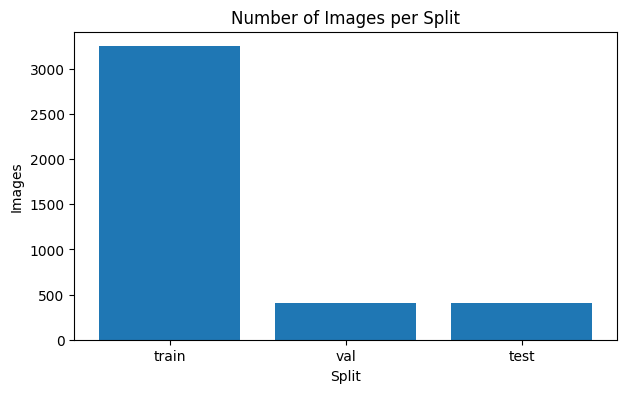

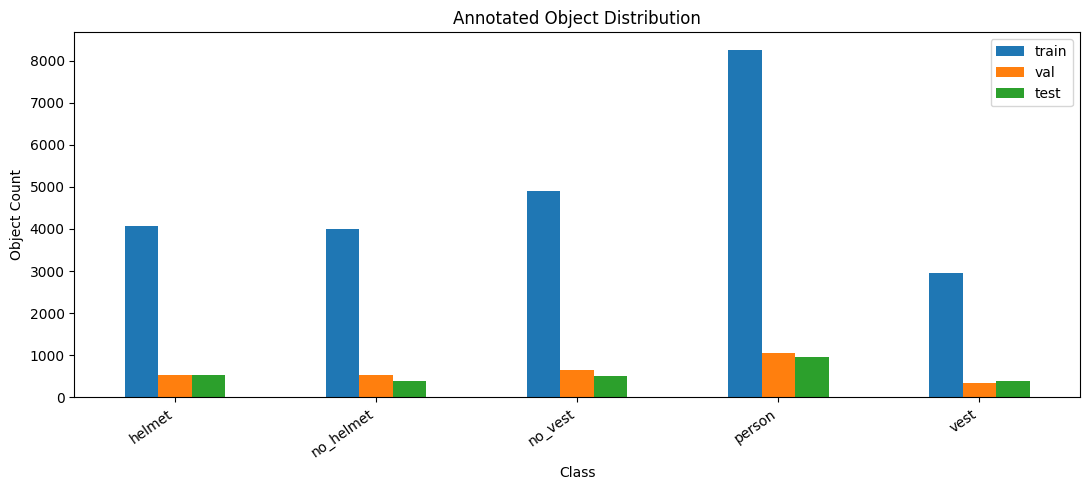

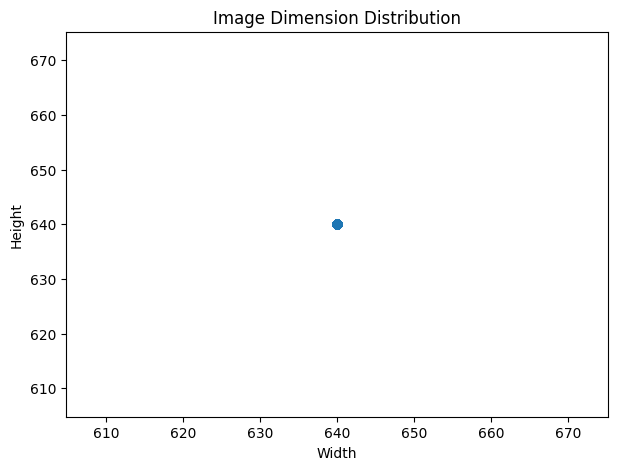

In [ ]:
def collect_dataset_statistics():
    split_rows = []
    class_counts = defaultdict(Counter)
    image_rows = []
    missing_label_records = []

    for split_name in ["train", "val", "test"]:
        object_total = 0
        images = list_images(SPLIT_IMAGE_DIRS[split_name])

        for image_path in images:
            label_path = matching_label_path(image_path, SPLIT_LABEL_DIRS[split_name])
            if not label_path.exists():
                missing_label_records.append((split_name, image_path.name))
                labels = []
            else:
                labels = read_yolo_label_file(label_path)

            with Image.open(image_path) as image:
                width, height = image.size

            image_rows.append({
                "split": split_name,
                "image": image_path.name,
                "width": width,
                "height": height,
                "objects": len(labels),
            })

            object_total += len(labels)
            for class_id, *_ in labels:
                if 0 <= class_id < NUM_CLASSES:
                    class_counts[split_name][class_id] += 1

        split_rows.append({
            "split": split_name,
            "images": len(images),
            "label_files": len(list(SPLIT_LABEL_DIRS[split_name].glob("*.txt"))),
            "annotated_objects": object_total,
            "average_objects_per_image": object_total / len(images) if images else 0,
        })

    return (
        pd.DataFrame(split_rows),
        class_counts,
        pd.DataFrame(image_rows),
        missing_label_records,
    )

split_summary_df, class_counts_by_split, image_sizes_df, missing_labels = collect_dataset_statistics()
display(split_summary_df)
print("Missing matching label files:", len(missing_labels))

class_rows = []
for class_id, class_name in enumerate(CLASS_NAMES):
    row = {"class_id": class_id, "class_name": class_name}
    for split_name in ["train", "val", "test"]:
        row[split_name] = class_counts_by_split[split_name][class_id]
    row["total"] = row["train"] + row["val"] + row["test"]
    class_rows.append(row)

class_distribution_df = pd.DataFrame(class_rows)
display(class_distribution_df)

plt.figure(figsize=(7, 4))
plt.bar(split_summary_df["split"], split_summary_df["images"])
plt.title("Number of Images per Split")
plt.xlabel("Split")
plt.ylabel("Images")
plt.show()

class_distribution_df.set_index("class_name")[["train", "val", "test"]].plot(
    kind="bar", figsize=(11, 5)
)
plt.title("Annotated Object Distribution")
plt.xlabel("Class")
plt.ylabel("Object Count")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
plt.scatter(image_sizes_df["width"], image_sizes_df["height"], alpha=0.35)
plt.title("Image Dimension Distribution")
plt.xlabel("Width")
plt.ylabel("Height")
plt.show()

## 8. EDA: visualise annotations on random training images

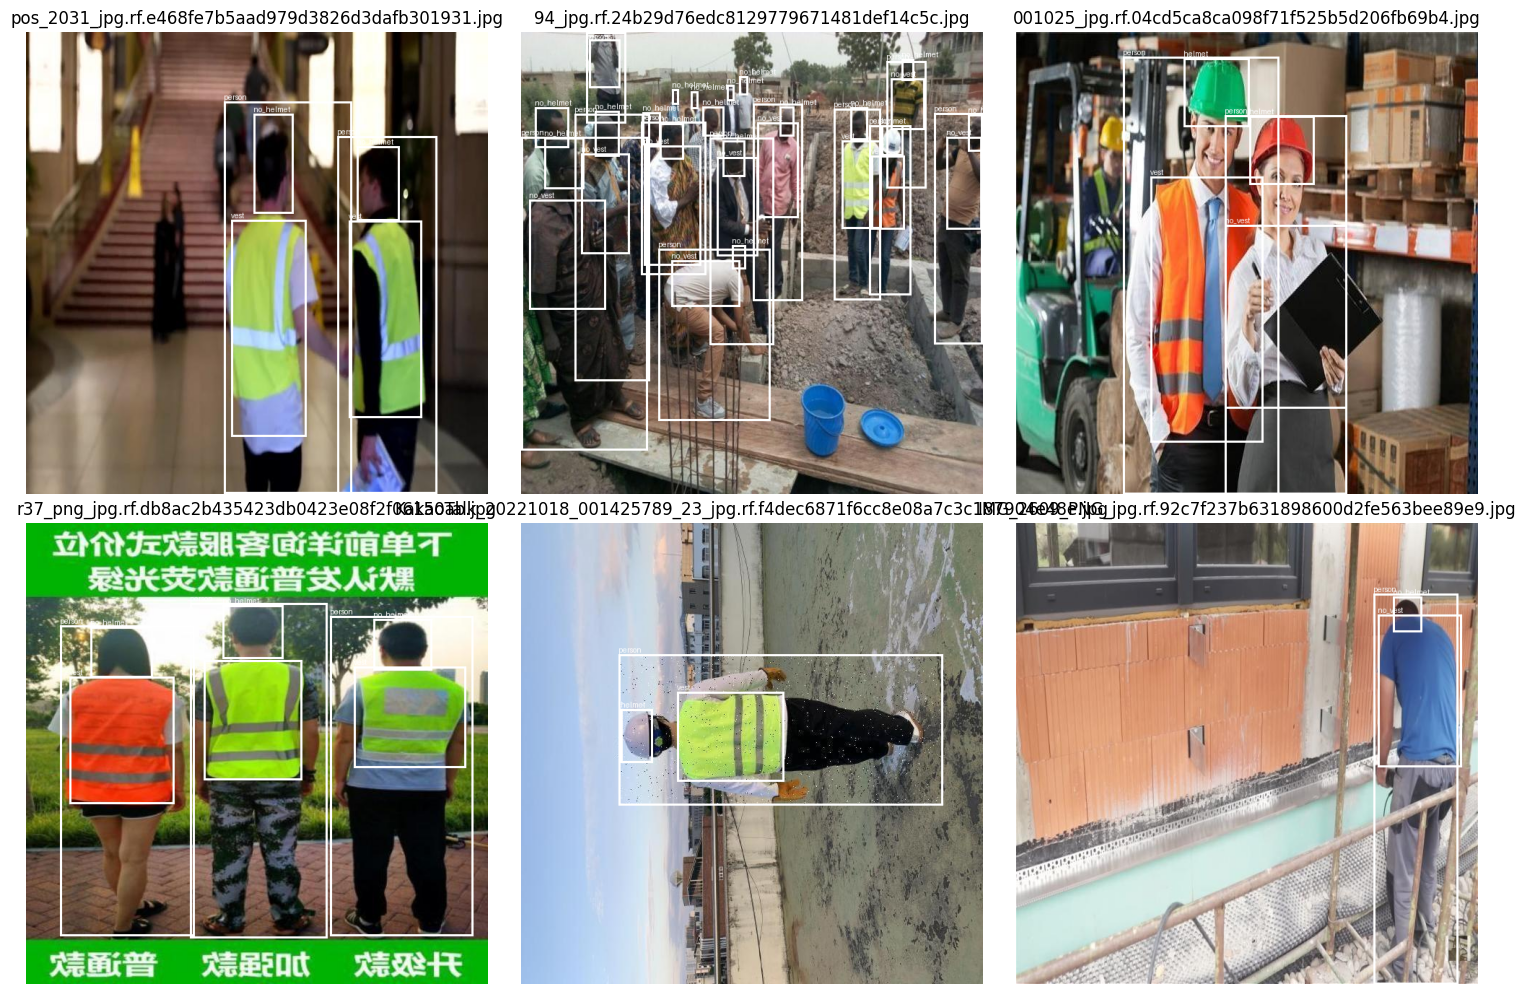

In [ ]:
def yolo_to_pixel_box(x_center, y_center, width, height, image_width, image_height):
    box_width = width * image_width
    box_height = height * image_height
    x1 = int(x_center * image_width - box_width / 2)
    y1 = int(y_center * image_height - box_height / 2)
    x2 = int(x_center * image_width + box_width / 2)
    y2 = int(y_center * image_height + box_height / 2)
    return x1, y1, x2, y2


def draw_yolo_annotations(image_path: Path, label_path: Path):
    image = Image.open(image_path).convert("RGB")
    draw = ImageDraw.Draw(image)
    image_width, image_height = image.size

    for class_id, x_center, y_center, width, height in read_yolo_label_file(label_path):
        x1, y1, x2, y2 = yolo_to_pixel_box(
            x_center, y_center, width, height, image_width, image_height
        )
        draw.rectangle([x1, y1, x2, y2], width=3)
        class_name = CLASS_NAMES[class_id] if 0 <= class_id < NUM_CLASSES else str(class_id)
        draw.text((max(0, x1), max(0, y1 - 12)), class_name)
    return image

sample_paths = random.sample(train_images, k=min(6, len(train_images)))
plt.figure(figsize=(15, 10))
for index, image_path in enumerate(sample_paths, start=1):
    label_path = matching_label_path(image_path, SPLIT_LABEL_DIRS["train"])
    annotated_image = draw_yolo_annotations(image_path, label_path)
    plt.subplot(2, 3, index)
    plt.imshow(annotated_image)
    plt.title(image_path.name)
    plt.axis("off")
plt.tight_layout()
plt.show()

## 9. Data preprocessing: validate images and YOLO annotations

In [ ]:
def validate_dataset():
    issues = []
    valid_object_count = 0

    for split_name in ["train", "val", "test"]:
        for image_path in list_images(SPLIT_IMAGE_DIRS[split_name]):
            label_path = matching_label_path(image_path, SPLIT_LABEL_DIRS[split_name])

            try:
                with Image.open(image_path) as image:
                    image.verify()
            except Exception as error:
                issues.append({
                    "split": split_name,
                    "file": str(image_path),
                    "issue": f"Corrupt image: {error}",
                })
                continue

            if not label_path.exists():
                issues.append({
                    "split": split_name,
                    "file": str(label_path),
                    "issue": "Missing label file",
                })
                continue

            try:
                labels = read_yolo_label_file(label_path)
            except Exception as error:
                issues.append({
                    "split": split_name,
                    "file": str(label_path),
                    "issue": str(error),
                })
                continue

            for class_id, x_center, y_center, width, height in labels:
                if not 0 <= class_id < NUM_CLASSES:
                    issues.append({
                        "split": split_name,
                        "file": str(label_path),
                        "issue": f"Invalid class ID: {class_id}",
                    })
                    continue
                if not all(0 <= value <= 1 for value in [x_center, y_center, width, height]):
                    issues.append({
                        "split": split_name,
                        "file": str(label_path),
                        "issue": "Bounding-box value outside 0–1",
                    })
                    continue
                if width <= 0 or height <= 0:
                    issues.append({
                        "split": split_name,
                        "file": str(label_path),
                        "issue": "Non-positive bounding-box size",
                    })
                    continue
                valid_object_count += 1

    return pd.DataFrame(issues), valid_object_count

validation_issues_df, valid_object_count = validate_dataset()
print("Valid annotated objects:", valid_object_count)
print("Detected issues:", len(validation_issues_df))
if len(validation_issues_df):
    display(validation_issues_df.head(30))
else:
    print("No structural problems were detected.")

Valid annotated objects: 30064
Detected issues: 0
No structural problems were detected.


## 10. Train/validation/test split

The dataset is already separated into `train`, `valid`, and `test`, so this project preserves those splits. It does not randomly split the files again.

For CNN and EfficientNet, every YOLO bounding box is converted into an object crop while retaining its original split. YOLO continues to use the original full images.

In [ ]:
CLASSIFICATION_ROOT = Path("/content/ppe_classification_crops")
REBUILD_CROPS = True
MIN_CROP_SIZE = 20
BOX_CONTEXT = 0.05


def safe_folder_name(name: str):
    return "".join(
        character if character.isalnum() or character in "-_" else "_"
        for character in str(name)
    )

CLASS_FOLDER_NAMES = [safe_folder_name(name) for name in CLASS_NAMES]


def create_classification_crops():
    if REBUILD_CROPS and CLASSIFICATION_ROOT.exists():
        shutil.rmtree(CLASSIFICATION_ROOT)

    crop_rows = []
    skipped_rows = []

    for split_name in ["train", "val", "test"]:
        for class_folder in CLASS_FOLDER_NAMES:
            (CLASSIFICATION_ROOT / split_name / class_folder).mkdir(
                parents=True, exist_ok=True
            )

        for image_path in list_images(SPLIT_IMAGE_DIRS[split_name]):
            label_path = matching_label_path(image_path, SPLIT_LABEL_DIRS[split_name])
            labels = read_yolo_label_file(label_path)
            if not labels:
                continue

            image = Image.open(image_path).convert("RGB")
            image_width, image_height = image.size

            for object_index, (class_id, x_center, y_center, width, height) in enumerate(labels):
                if not 0 <= class_id < NUM_CLASSES:
                    continue

                x1, y1, x2, y2 = yolo_to_pixel_box(
                    x_center, y_center, width, height, image_width, image_height
                )

                context_x = int((x2 - x1) * BOX_CONTEXT)
                context_y = int((y2 - y1) * BOX_CONTEXT)
                x1 = max(0, x1 - context_x)
                y1 = max(0, y1 - context_y)
                x2 = min(image_width, x2 + context_x)
                y2 = min(image_height, y2 + context_y)

                if (x2 - x1) < MIN_CROP_SIZE or (y2 - y1) < MIN_CROP_SIZE:
                    skipped_rows.append((split_name, image_path.name, object_index))
                    continue

                class_folder = CLASS_FOLDER_NAMES[class_id]
                output_name = f"{image_path.stem}_object_{object_index:03d}.jpg"
                output_path = (
                    CLASSIFICATION_ROOT / split_name / class_folder / output_name
                )
                image.crop((x1, y1, x2, y2)).save(output_path, quality=95)

                crop_rows.append({
                    "split": split_name,
                    "source_image": image_path.name,
                    "crop_path": str(output_path),
                    "class_id": class_id,
                    "class_name": CLASS_NAMES[class_id],
                    "crop_width": x2 - x1,
                    "crop_height": y2 - y1,
                })

    return pd.DataFrame(crop_rows), skipped_rows

crop_records_df, skipped_crops = create_classification_crops()
print("Created object crops:", len(crop_records_df))
print("Skipped very small crops:", len(skipped_crops))
display(crop_records_df.head())

display(
    crop_records_df.groupby(["split", "class_name"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=CLASS_NAMES, fill_value=0)
)

Created object crops: 25204
Skipped very small crops: 4860


,split,source_image,crop_path,class_id,class_name,crop_width,crop_height
0,train,-1429-_png_jpg.rf.7dcaf10c0ec272743f87799af6af...,/content/ppe_classification_crops/train/helmet...,0,helmet,60,41
1,train,-1429-_png_jpg.rf.7dcaf10c0ec272743f87799af6af...,/content/ppe_classification_crops/train/helmet...,0,helmet,50,30
2,train,-1429-_png_jpg.rf.7dcaf10c0ec272743f87799af6af...,/content/ppe_classification_crops/train/no_ves...,2,no_vest,107,141
3,train,-1429-_png_jpg.rf.7dcaf10c0ec272743f87799af6af...,/content/ppe_classification_crops/train/no_ves...,2,no_vest,95,157
4,train,-1429-_png_jpg.rf.7dcaf10c0ec272743f87799af6af...,/content/ppe_classification_crops/train/person...,3,person,139,405


class_name,helmet,no_helmet,no_vest,person,vest
split,,,,,
test,414,268,446,889,369
train,2997,2601,4197,7612,2678
val,447,375,570,997,344


## 11. Load classification datasets and define data augmentation

In [ ]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.keras.utils.image_dataset_from_directory(
    CLASSIFICATION_ROOT / "train",
    labels="inferred",
    label_mode="int",
    class_names=CLASS_FOLDER_NAMES,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    CLASSIFICATION_ROOT / "val",
    labels="inferred",
    label_mode="int",
    class_names=CLASS_FOLDER_NAMES,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    CLASSIFICATION_ROOT / "test",
    labels="inferred",
    label_mode="int",
    class_names=CLASS_FOLDER_NAMES,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

DATA_AUGMENTATION = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.06),
        layers.RandomZoom(0.12),
        layers.RandomContrast(0.15),
        layers.RandomTranslation(0.05, 0.05),
    ],
    name="data_augmentation",
)

training_labels = crop_records_df.loc[
    crop_records_df["split"] == "train", "class_id"
].to_numpy()
classes_present = np.unique(training_labels)
class_weight_values = compute_class_weight(
    class_weight="balanced",
    classes=classes_present,
    y=training_labels,
)
CLASS_WEIGHTS = {
    int(class_id): float(weight)
    for class_id, weight in zip(classes_present, class_weight_values)
}
print("Class weights:", CLASS_WEIGHTS)

Found 20085 files belonging to 5 classes.
Found 2733 files belonging to 5 classes.
Found 2386 files belonging to 5 classes.
Class weights: {0: 1.3403403403403404, 1: 1.544405997693195, 2: 0.9571122230164403, 3: 0.5277193904361535, 4: 1.5}


## 12. Preview augmented training crops

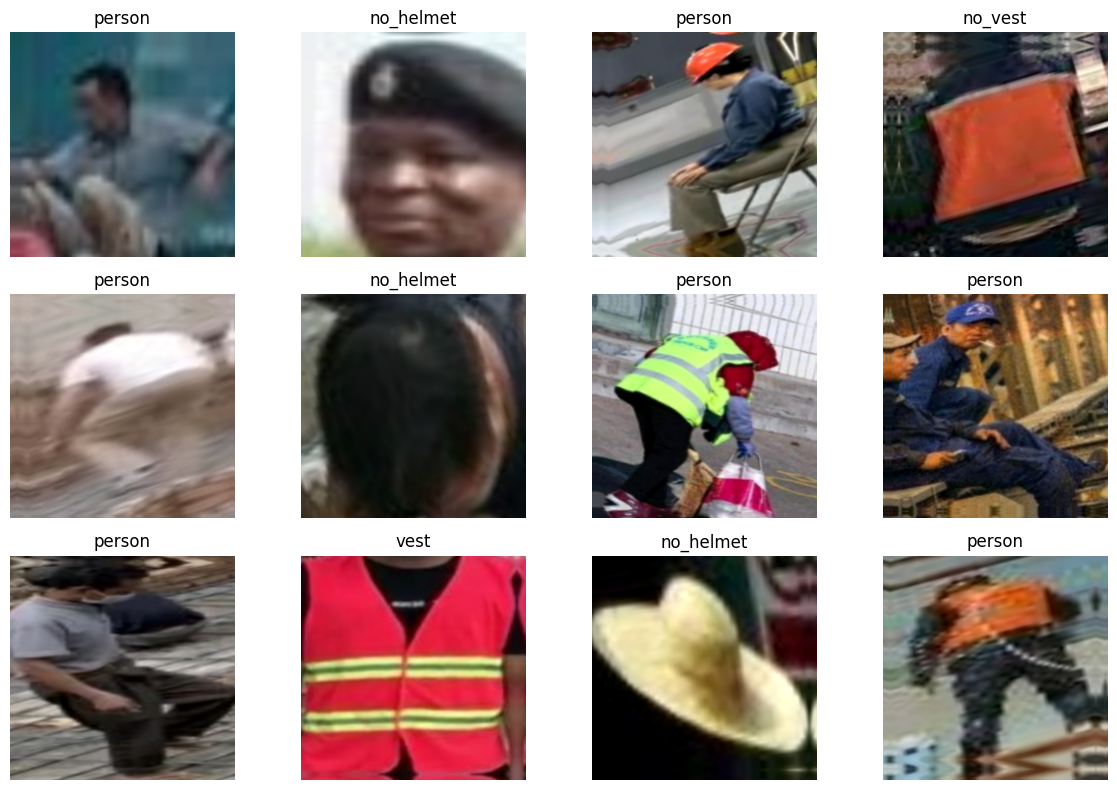

In [ ]:
for images, labels in train_ds.take(1):
    augmented_images = DATA_AUGMENTATION(images, training=True)
    plt.figure(figsize=(12, 8))
    display_count = min(12, int(images.shape[0]))
    for index in range(display_count):
        plt.subplot(3, 4, index + 1)
        plt.imshow(tf.cast(augmented_images[index], tf.uint8))
        plt.title(CLASS_NAMES[int(labels[index])])
        plt.axis("off")
    plt.tight_layout()
    plt.show()

## 13. Build the custom CNN

In [ ]:
def build_custom_cnn(num_classes: int):
    inputs = keras.Input(shape=(*IMAGE_SIZE, 3))
    x = DATA_AUGMENTATION(inputs)
    x = layers.Rescaling(1.0 / 255)(x)

    for filters, dropout_rate in [
        (32, 0.10),
        (64, 0.15),
        (128, 0.20),
        (256, 0.25),
    ]:
        x = layers.Conv2D(filters, 3, padding="same", use_bias=False)(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation("relu")(x)
        x = layers.Conv2D(filters, 3, padding="same", use_bias=False)(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation("relu")(x)
        x = layers.MaxPooling2D()(x)
        x = layers.Dropout(dropout_rate)(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.40)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(inputs, outputs, name="custom_ppe_cnn")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

CNN_MODEL = build_custom_cnn(NUM_CLASSES)
CNN_MODEL.summary()

Model: "custom_ppe_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,243,237 (4.74 MB)

 Trainable params: 1,240,805 (4.73 MB)

 Non-trainable params: 2,432 (9.50 KB)

## 14. Train the custom CNN

In [ ]:
MODEL_DIR = Path("/content/models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

CNN_CHECKPOINT = MODEL_DIR / "best_custom_cnn.keras"
CNN_EPOCHS = 25

cnn_callbacks = [
    keras.callbacks.ModelCheckpoint(
        CNN_CHECKPOINT,
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1,
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-6,
        verbose=1,
    ),
]

cnn_history = CNN_MODEL.fit(
    train_ds,
    validation_data=val_ds,
    epochs=CNN_EPOCHS,
    class_weight=CLASS_WEIGHTS,
    callbacks=cnn_callbacks,
)

Epoch 1/25
628/628 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step - accuracy: 0.5318 - loss: 1.2534
Epoch 1: val_accuracy improved from None to 0.66923, saving model to /content/models/best_custom_cnn.keras

Epoch 1: finished saving model to /content/models/best_custom_cnn.keras
628/628 ━━━━━━━━━━━━━━━━━━━━ 219s 327ms/step - accuracy: 0.5837 - loss: 1.1010 - val_accuracy: 0.6692 - val_loss: 0.8690 - learning_rate: 0.0010
Epoch 2/25
628/628 ━━━━━━━━━━━━━━━━━━━━ 0s 318ms/step - accuracy: 0.6689 - loss: 0.8848
Epoch 2: val_accuracy improved from 0.66923 to 0.72850, saving model to /content/models/best_custom_cnn.keras

Epoch 2: finished saving model to /content/models/best_custom_cnn.keras
628/628 ━━━━━━━━━━━━━━━━━━━━ 205s 326ms/step - accuracy: 0.6841 - loss: 0.8507 - val_accuracy: 0.7285 - val_loss: 0.7359 - learning_rate: 0.0010
Epoch 3/25
628/628 ━━━━━━━━━━━━━━━━━━━━ 0s 318ms/step - accuracy: 0.7036 - loss: 0.7902
Epoch 3: val_accuracy did not improve from 0.72850
628/628 ━━━━━━━━━━━━━━━━━━━━ 205

## 15. Plot CNN learning curves

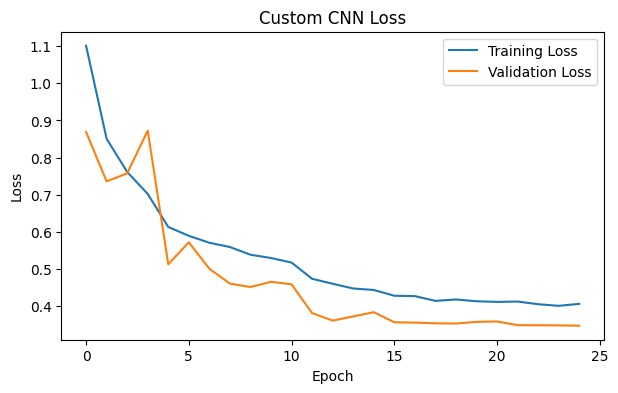

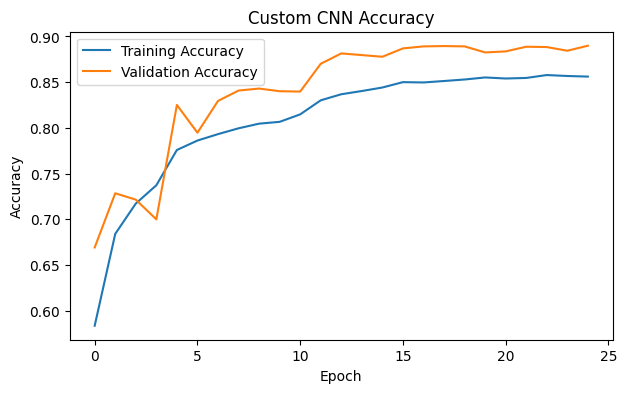

In [ ]:
def plot_training_history(history, title_prefix):
    history_df = pd.DataFrame(history.history)

    plt.figure(figsize=(7, 4))
    plt.plot(history_df["loss"], label="Training Loss")
    plt.plot(history_df["val_loss"], label="Validation Loss")
    plt.title(f"{title_prefix} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(history_df["accuracy"], label="Training Accuracy")
    plt.plot(history_df["val_accuracy"], label="Validation Accuracy")
    plt.title(f"{title_prefix} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

plot_training_history(cnn_history, "Custom CNN")

## 16. Build the EfficientNetB0 transfer-learning model

In [ ]:
def build_efficientnet_model(num_classes: int):
    inputs = keras.Input(shape=(*IMAGE_SIZE, 3))
    x = DATA_AUGMENTATION(inputs)

    base_model = keras.applications.EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=(*IMAGE_SIZE, 3),
    )
    base_model.trainable = False

    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.35)(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.30)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return keras.Model(inputs, outputs, name="efficientnetb0_ppe"), base_model

EFFICIENTNET_MODEL, EFFICIENTNET_BASE = build_efficientnet_model(NUM_CLASSES)
EFFICIENTNET_MODEL.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
EFFICIENTNET_MODEL.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "efficientnetb0_ppe"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,383,912 (16.72 MB)

 Trainable params: 331,781 (1.27 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

## 17. Train EfficientNetB0 with a frozen backbone

In [ ]:
EFFICIENTNET_CHECKPOINT = MODEL_DIR / "best_efficientnetb0.keras"
TRANSFER_EPOCHS = 12

transfer_callbacks = [
    keras.callbacks.ModelCheckpoint(
        EFFICIENTNET_CHECKPOINT,
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1,
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-6,
        verbose=1,
    ),
]

transfer_history_stage1 = EFFICIENTNET_MODEL.fit(
    train_ds,
    validation_data=val_ds,
    epochs=TRANSFER_EPOCHS,
    class_weight=CLASS_WEIGHTS,
    callbacks=transfer_callbacks,
)

Epoch 1/12
628/628 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.7487 - loss: 0.8070
Epoch 1: val_accuracy improved from None to 0.88621, saving model to /content/models/best_efficientnetb0.keras

Epoch 1: finished saving model to /content/models/best_efficientnetb0.keras
628/628 ━━━━━━━━━━━━━━━━━━━━ 75s 101ms/step - accuracy: 0.7938 - loss: 0.6419 - val_accuracy: 0.8862 - val_loss: 0.3543 - learning_rate: 0.0010
Epoch 2/12
628/628 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.8295 - loss: 0.4787
Epoch 2: val_accuracy improved from 0.88621 to 0.90816, saving model to /content/models/best_efficientnetb0.keras

Epoch 2: finished saving model to /content/models/best_efficientnetb0.keras
628/628 ━━━━━━━━━━━━━━━━━━━━ 77s 94ms/step - accuracy: 0.8328 - loss: 0.4623 - val_accuracy: 0.9082 - val_loss: 0.2981 - learning_rate: 0.0010
Epoch 3/12
628/628 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.8524 - loss: 0.4195
Epoch 3: val_accuracy did not improve from 0.90816
628/628 ━━━━━━━━━━━━━━

## 18. Fine-tune the final EfficientNetB0 layers

Epoch 13/20
628/628 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.8984 - loss: 0.2795
Epoch 13: val_accuracy improved from 0.92316 to 0.92792, saving model to /content/models/best_efficientnetb0.keras

Epoch 13: finished saving model to /content/models/best_efficientnetb0.keras
628/628 ━━━━━━━━━━━━━━━━━━━━ 80s 107ms/step - accuracy: 0.8997 - loss: 0.2763 - val_accuracy: 0.9279 - val_loss: 0.2593 - learning_rate: 1.0000e-05
Epoch 14/20
628/628 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.9011 - loss: 0.2672
Epoch 14: val_accuracy improved from 0.92792 to 0.93231, saving model to /content/models/best_efficientnetb0.keras

Epoch 14: finished saving model to /content/models/best_efficientnetb0.keras
628/628 ━━━━━━━━━━━━━━━━━━━━ 66s 105ms/step - accuracy: 0.9022 - loss: 0.2652 - val_accuracy: 0.9323 - val_loss: 0.2514 - learning_rate: 1.0000e-05
Epoch 15/20
628/628 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.9054 - loss: 0.2620
Epoch 15: val_accuracy improved from 0.93231 to 0.9330

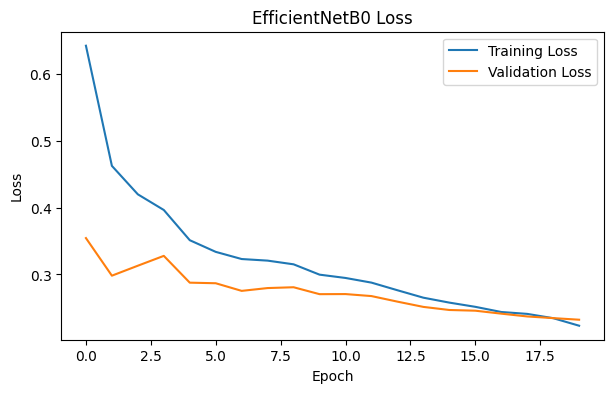

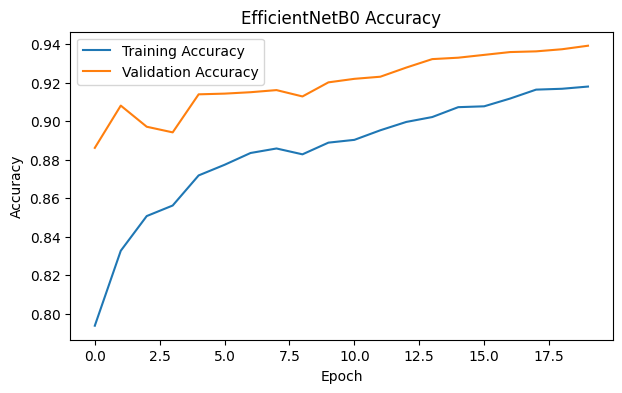

In [ ]:
EFFICIENTNET_BASE.trainable = True
for layer in EFFICIENTNET_BASE.layers[:-30]:
    layer.trainable = False
for layer in EFFICIENTNET_BASE.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

EFFICIENTNET_MODEL.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

FINE_TUNE_EPOCHS = 8
initial_epoch = len(transfer_history_stage1.history["loss"])
transfer_history_stage2 = EFFICIENTNET_MODEL.fit(
    train_ds,
    validation_data=val_ds,
    initial_epoch=initial_epoch,
    epochs=initial_epoch + FINE_TUNE_EPOCHS,
    class_weight=CLASS_WEIGHTS,
    callbacks=transfer_callbacks,
)

efficientnet_history = {}
for metric_name in transfer_history_stage1.history:
    efficientnet_history[metric_name] = (
        transfer_history_stage1.history[metric_name]
        + transfer_history_stage2.history.get(metric_name, [])
    )

class CombinedHistory:
    history = efficientnet_history

plot_training_history(CombinedHistory(), "EfficientNetB0")

## 19. Evaluate CNN and EfficientNetB0


Custom CNN classification report
              precision    recall  f1-score   support

      helmet       0.90      0.90      0.90       414
   no_helmet       0.79      0.88      0.84       268
     no_vest       0.83      0.83      0.83       446
      person       0.96      0.92      0.94       889
        vest       0.91      0.92      0.92       369

    accuracy                           0.89      2386
   macro avg       0.88      0.89      0.88      2386
weighted avg       0.90      0.89      0.90      2386



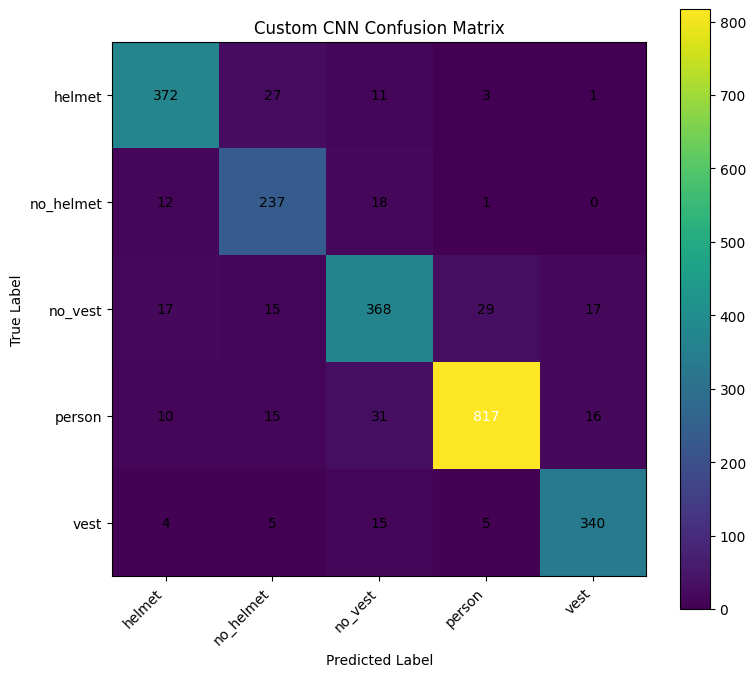


EfficientNetB0 classification report
              precision    recall  f1-score   support

      helmet       0.94      0.94      0.94       414
   no_helmet       0.86      0.92      0.89       268
     no_vest       0.90      0.90      0.90       446
      person       0.97      0.95      0.96       889
        vest       0.94      0.96      0.95       369

    accuracy                           0.94      2386
   macro avg       0.92      0.93      0.93      2386
weighted avg       0.94      0.94      0.94      2386



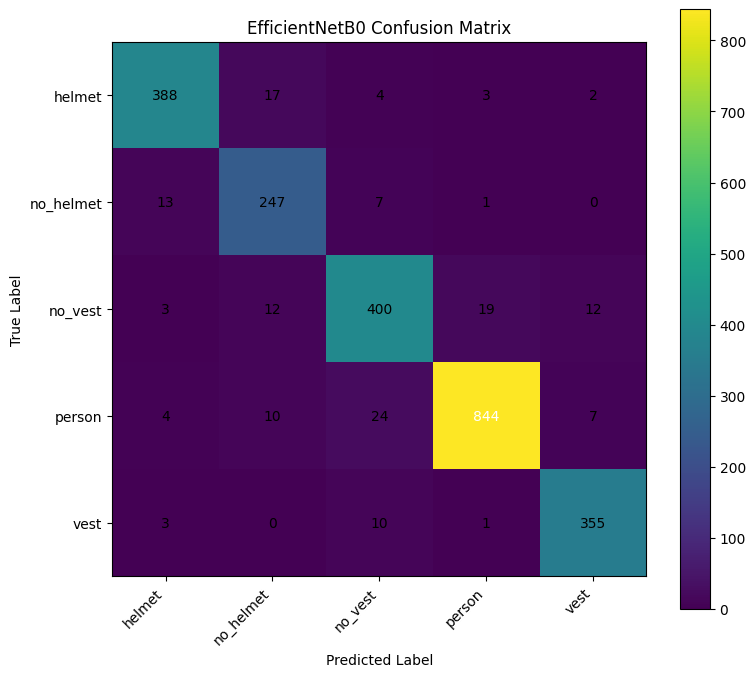

,model,accuracy,macro_precision,macro_recall,macro_f1
0,Custom CNN,0.894384,0.876875,0.889682,0.882695
1,EfficientNetB0,0.936295,0.924610,0.933428,0.928784


In [ ]:
def collect_true_labels(dataset):
    labels = []
    for _, batch_labels in dataset:
        labels.extend(batch_labels.numpy().astype(int).tolist())
    return np.array(labels)


def evaluate_classifier(model_path: Path, dataset, model_name: str):
    model = keras.models.load_model(model_path)
    probabilities = model.predict(dataset, verbose=0)
    predictions = probabilities.argmax(axis=1)
    true_labels = collect_true_labels(dataset)

    accuracy = accuracy_score(true_labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(
        true_labels,
        predictions,
        average="macro",
        zero_division=0,
    )

    print(f"\n{model_name} classification report")
    print(classification_report(
        true_labels,
        predictions,
        labels=list(range(NUM_CLASSES)),
        target_names=CLASS_NAMES,
        zero_division=0,
    ))

    matrix = confusion_matrix(
        true_labels,
        predictions,
        labels=list(range(NUM_CLASSES)),
    )
    plt.figure(figsize=(8, 7))
    plt.imshow(matrix, interpolation="nearest")
    plt.title(f"{model_name} Confusion Matrix")
    plt.colorbar()
    tick_positions = np.arange(NUM_CLASSES)
    plt.xticks(tick_positions, CLASS_NAMES, rotation=45, ha="right")
    plt.yticks(tick_positions, CLASS_NAMES)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

    threshold = matrix.max() / 2 if matrix.size else 0
    for row in range(matrix.shape[0]):
        for column in range(matrix.shape[1]):
            plt.text(
                column,
                row,
                str(matrix[row, column]),
                ha="center",
                va="center",
                color="white" if matrix[row, column] > threshold else "black",
            )
    plt.tight_layout()
    plt.show()

    return {
        "model": model_name,
        "accuracy": accuracy,
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": f1,
    }, model

cnn_metrics, BEST_CNN = evaluate_classifier(
    CNN_CHECKPOINT, test_ds, "Custom CNN"
)
efficientnet_metrics, BEST_EFFICIENTNET = evaluate_classifier(
    EFFICIENTNET_CHECKPOINT, test_ds, "EfficientNetB0"
)

classification_results_df = pd.DataFrame([cnn_metrics, efficientnet_metrics])
display(classification_results_df)

## 20. Select and save the best classifier using validation accuracy

In [ ]:
cnn_best_val_accuracy = max(cnn_history.history["val_accuracy"])
efficientnet_best_val_accuracy = max(efficientnet_history["val_accuracy"])

if efficientnet_best_val_accuracy >= cnn_best_val_accuracy:
    BEST_CLASSIFIER_NAME = "EfficientNetB0"
    BEST_CLASSIFIER_SOURCE = EFFICIENTNET_CHECKPOINT
else:
    BEST_CLASSIFIER_NAME = "Custom CNN"
    BEST_CLASSIFIER_SOURCE = CNN_CHECKPOINT

BEST_CLASSIFIER_PATH = MODEL_DIR / "best_ppe_classifier.keras"
shutil.copy2(BEST_CLASSIFIER_SOURCE, BEST_CLASSIFIER_PATH)

print("Best classifier:", BEST_CLASSIFIER_NAME)
print("CNN best validation accuracy:", cnn_best_val_accuracy)
print("EfficientNetB0 best validation accuracy:", efficientnet_best_val_accuracy)
print("Saved classifier:", BEST_CLASSIFIER_PATH)

Best classifier: EfficientNetB0
CNN best validation accuracy: 0.8898646235466003
EfficientNetB0 best validation accuracy: 0.9392609000205994
Saved classifier: /content/models/best_ppe_classifier.keras


## 21. Train YOLO on the original full images

In [ ]:
YOLO_WEIGHTS = "yolo11n.pt"
YOLO_EPOCHS = 50
YOLO_IMAGE_SIZE = 640
YOLO_BATCH_SIZE = 16
YOLO_PROJECT_DIR = Path("/content/yolo_runs")
YOLO_RUN_NAME = "ppe_yolo11n"

YOLO_MODEL = YOLO(YOLO_WEIGHTS)
yolo_train_results = YOLO_MODEL.train(
    data=str(PREPARED_YAML),
    epochs=YOLO_EPOCHS,
    imgsz=YOLO_IMAGE_SIZE,
    batch=YOLO_BATCH_SIZE,
    patience=10,
    seed=SEED,
    project=str(YOLO_PROJECT_DIR),
    name=YOLO_RUN_NAME,
    pretrained=True,
    plots=True,
    workers=2,
)

YOLO_BEST_SOURCE = YOLO_PROJECT_DIR / YOLO_RUN_NAME / "weights" / "best.pt"
if not YOLO_BEST_SOURCE.exists():
    candidates = sorted(YOLO_PROJECT_DIR.glob(f"{YOLO_RUN_NAME}*/weights/best.pt"))
    if not candidates:
        raise FileNotFoundError("Could not locate YOLO best.pt after training.")
    YOLO_BEST_SOURCE = candidates[-1]

YOLO_BEST_PATH = MODEL_DIR / "ppe_yolo_best.pt"
shutil.copy2(YOLO_BEST_SOURCE, YOLO_BEST_PATH)
print("Saved YOLO detector:", YOLO_BEST_PATH)

Ultralytics 8.4.77 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/ppe_prepared.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=ppe_yolo11n, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, 

## 22. Display YOLO training curves and confusion matrices

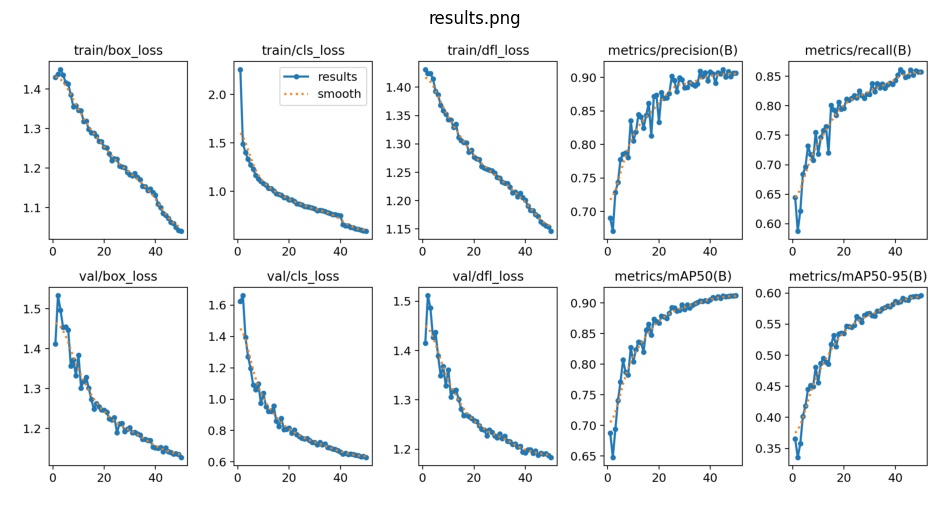

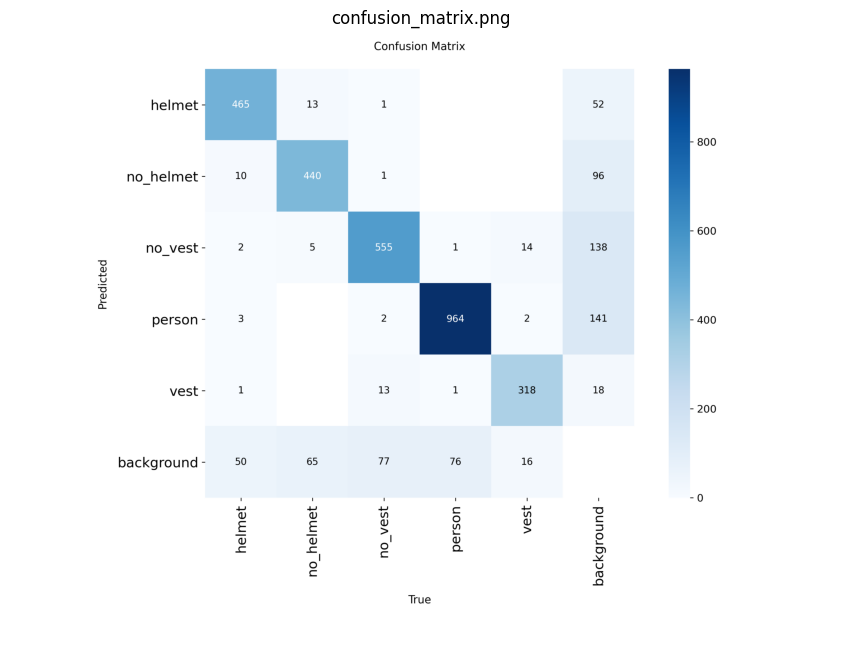

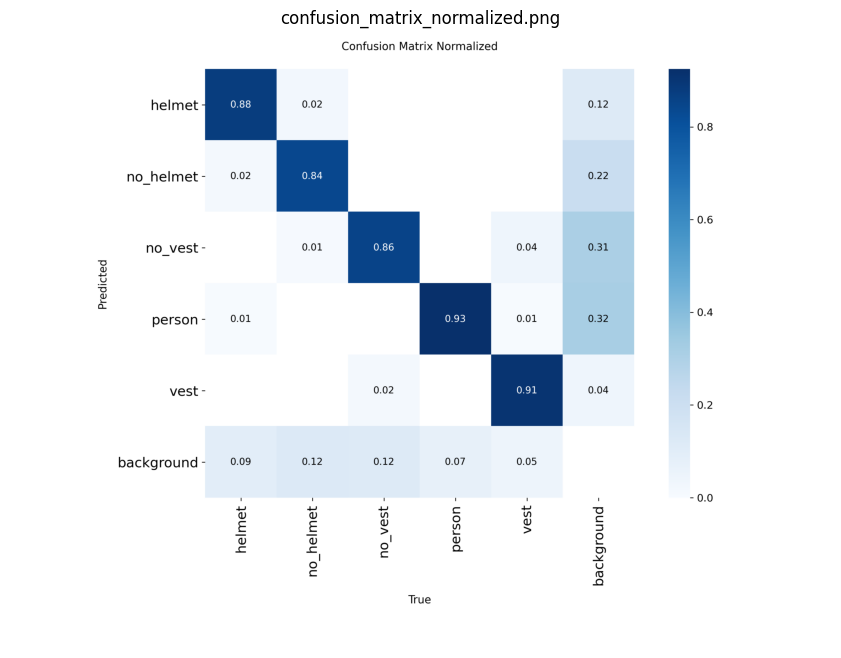

In [ ]:
yolo_run_dir = YOLO_BEST_SOURCE.parent.parent
for plot_name in [
    "results.png",
    "confusion_matrix.png",
    "confusion_matrix_normalized.png",
]:
    plot_path = yolo_run_dir / plot_name
    if plot_path.exists():
        plt.figure(figsize=(12, 8))
        plt.imshow(Image.open(plot_path))
        plt.title(plot_name)
        plt.axis("off")
        plt.show()

## 23. Evaluate YOLO on the supplied test split

In [ ]:
BEST_YOLO = YOLO(str(YOLO_BEST_PATH))
yolo_test_metrics = BEST_YOLO.val(
    data=str(PREPARED_YAML),
    split="test",
    imgsz=YOLO_IMAGE_SIZE,
    plots=True,
)

yolo_summary_df = pd.DataFrame([{
    "model": "YOLO11n",
    "precision": float(yolo_test_metrics.box.mp),
    "recall": float(yolo_test_metrics.box.mr),
    "mAP50": float(yolo_test_metrics.box.map50),
    "mAP50-95": float(yolo_test_metrics.box.map),
}])
display(yolo_summary_df)

if hasattr(yolo_test_metrics.box, "maps"):
    per_class_ap_df = pd.DataFrame({
        "class_name": CLASS_NAMES,
        "mAP50-95": [float(value) for value in yolo_test_metrics.box.maps],
    })
    display(per_class_ap_df)

Ultralytics 8.4.77 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,583,127 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 43.5±31.7 MB/s, size: 66.7 KB)
val: Scanning /content/dataset/HelmetConstruction/test/labels... 406 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 406/406 963.9it/s 0.4s
val: New cache created: /content/dataset/HelmetConstruction/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 26/26 3.4it/s 7.7s
                   all        406       2785      0.907      0.824       0.87      0.585
                helmet        270        529      0.917      0.836      0.883      0.571
             no_helmet        204        393      0.875      0.764      0.811      0.484
               no_vest        222        513      0.879      0.807      0.842      0.521
                person        405        954    

,model,precision,recall,mAP50,mAP50-95
0,YOLO11n,0.906808,0.824331,0.86981,0.585414


,class_name,mAP50-95
0,helmet,0.571203
1,no_helmet,0.484332
2,no_vest,0.521480
3,person,0.684177
4,vest,0.665880


## 24. Show the final model evaluation tables

In [ ]:
print("Classification: cropped-object task")
display(classification_results_df)

print("Object detection: complete-image task")
display(yolo_summary_df)

Classification: cropped-object task


,model,accuracy,macro_precision,macro_recall,macro_f1
0,Custom CNN,0.894384,0.876875,0.889682,0.882695
1,EfficientNetB0,0.936295,0.924610,0.933428,0.928784


Object detection: complete-image task


,model,precision,recall,mAP50,mAP50-95
0,YOLO11n,0.906808,0.824331,0.86981,0.585414


## 25. Test YOLO on random unseen test images

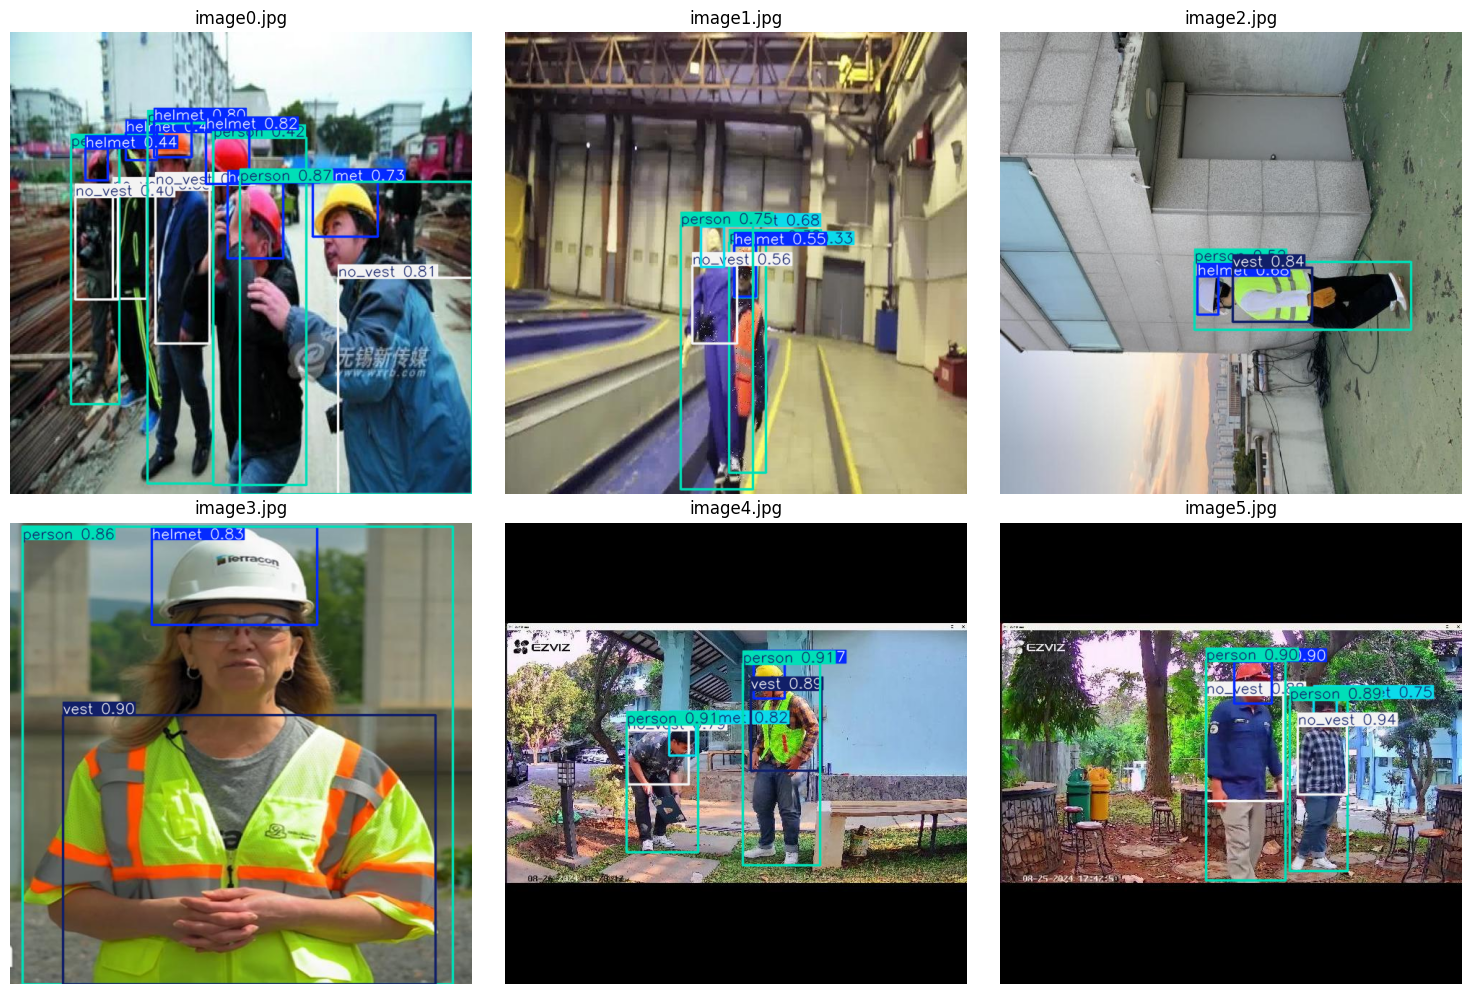

In [ ]:
test_images = list_images(SPLIT_IMAGE_DIRS["test"])
selected_test_images = random.sample(test_images, k=min(6, len(test_images)))

prediction_results = BEST_YOLO.predict(
    source=[str(path) for path in selected_test_images],
    conf=0.25,
    imgsz=YOLO_IMAGE_SIZE,
    save=False,
    verbose=False,
)

plt.figure(figsize=(15, 10))
for index, result in enumerate(prediction_results, start=1):
    plotted_image = cv2.cvtColor(result.plot(), cv2.COLOR_BGR2RGB)
    plt.subplot(2, 3, index)
    plt.imshow(plotted_image)
    plt.title(Path(result.path).name)
    plt.axis("off")
plt.tight_layout()
plt.show()

## 26. Upload and test a completely new image in Colab

Saving norpol_colourbox_1000.jpg to norpol_colourbox_1000 (1).jpg
Results saved to /content/new_image_predictions/predict


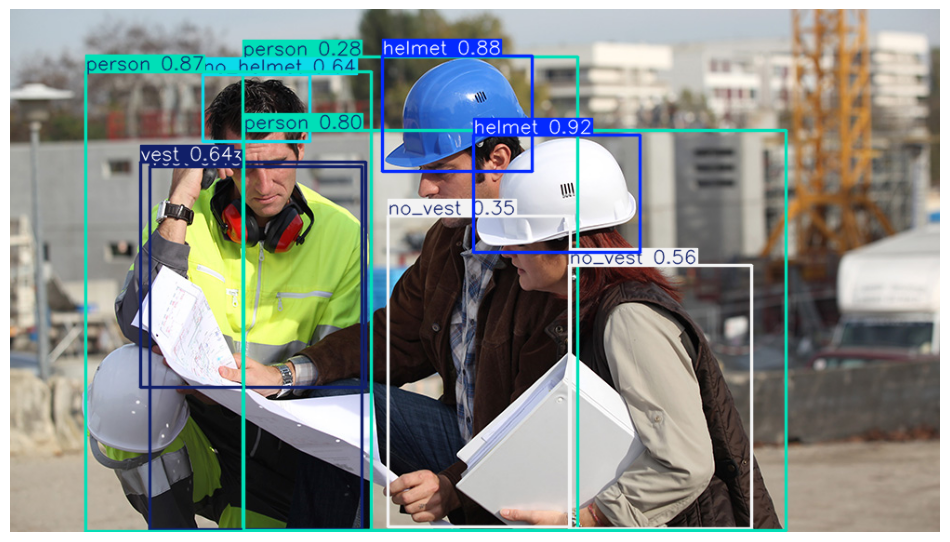

In [ ]:
try:
    from google.colab import files

    uploaded = files.upload()
    if uploaded:
        uploaded_image_path = Path(next(iter(uploaded.keys())))
        results = BEST_YOLO.predict(
            source=str(uploaded_image_path),
            conf=0.25,
            imgsz=YOLO_IMAGE_SIZE,
            save=True,
            project="/content/new_image_predictions",
            name="predict",
            exist_ok=True,
        )
        plotted_image = cv2.cvtColor(results[0].plot(), cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(12, 8))
        plt.imshow(plotted_image)
        plt.axis("off")
        plt.show()
except ImportError:
    print("This upload cell is intended for Google Colab.")